In [14]:
import scanpy as sc
import pandas as pd
import numpy as np

In [16]:
data_path='/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/annotated_CRC0322_NT_1_3000.tsv'
data=pd.read_csv(data_path,header=0,index_col=0).T
data.columns = [col.split(":")[1] if ":" in col else col for col in data.columns]
#########DECIDERE SE SELEZIONARE GENI DAL BULK O FARE I PIU VARIABILI SUL SC##########
select_gene=True

In [17]:
file_name = "gene_list.txt"
with open(file_name, "r") as f:
    gene_list = [line.strip() for line in f]
f.close()

In [18]:
gene_list=list(set(data.columns).intersection(gene_list))
if select_gene:
    data_sel=data[gene_list]

In [19]:
adata_selected = sc.AnnData(data_sel,dtype='float64')
adata_selected.var_names_make_unique()

adata_nosel = sc.AnnData(data,dtype='float64')
adata_nosel.var_names_make_unique()

/usr/local/mamba/envs/scampyno/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [22]:
n_pc=30
nn=10
res=0.35
res_sel=0.65

In [21]:
sc.pp.normalize_total(adata_selected, target_sum=1e4)
sc.pp.log1p(adata_selected)
sc.tl.pca(adata_selected, svd_solver='arpack')

#NN Graph 
sc.pp.neighbors(adata_selected, n_neighbors=nn, n_pcs=n_pc)

#UMAP
sc.tl.umap(adata_selected)

#Clustering Leiden
sc.tl.leiden(adata_selected, resolution=res_sel)

In [23]:
#CLUSTERING WITH LEIDEN not selected genes
sc.pp.filter_cells(adata_nosel, min_genes=100)
sc.pp.filter_genes(adata_nosel, min_cells=3)
#Normalizzazione e preprocessing
sc.pp.normalize_total(adata_nosel, target_sum=1e4)
sc.pp.log1p(adata_nosel)
sc.pp.highly_variable_genes(adata_nosel, n_top_genes=3000)
adata_nosel = adata_nosel[:, adata_nosel.var.highly_variable]
#PCA
sc.pp.scale(adata_nosel , max_value=10)
sc.tl.pca(adata_nosel , svd_solver='arpack')
#NN GRAPH
sc.pp.neighbors(adata_nosel , n_neighbors=nn, n_pcs=n_pc)
#UMAP
sc.tl.umap(adata_nosel)
#Clustering Leiden
sc.tl.leiden(adata_nosel, resolution=res)

/usr/local/mamba/envs/scampyno/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:843: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/mamba/envs/scampyno/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:843: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  view_to_actual(adata)


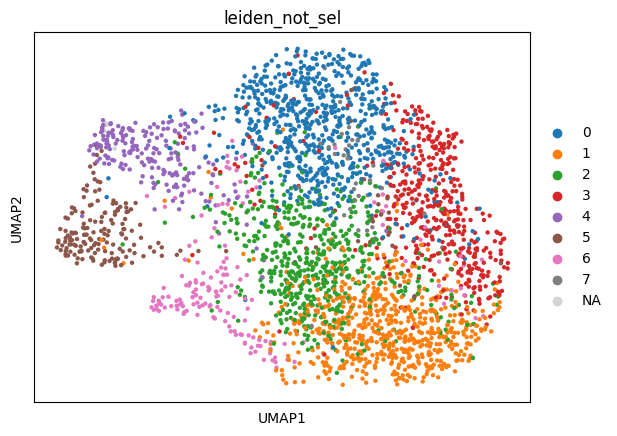

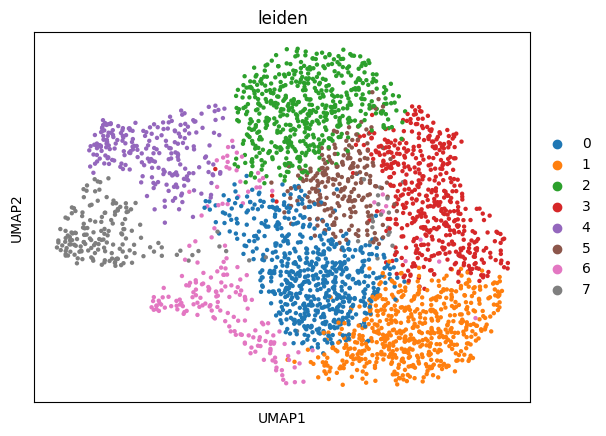

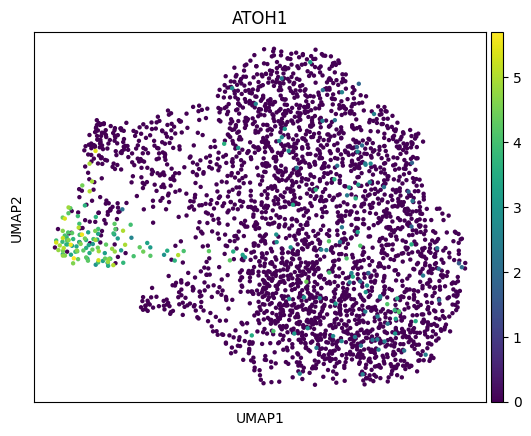

In [24]:
#Vedo umap
adata_selected.obs['leiden_not_sel'] = adata_nosel.obs['leiden']
sc.pl.umap(adata_selected, color='leiden_not_sel')
sc.pl.umap(adata_selected,color='leiden')
sc.pl.umap(adata_selected,color='ATOH1')

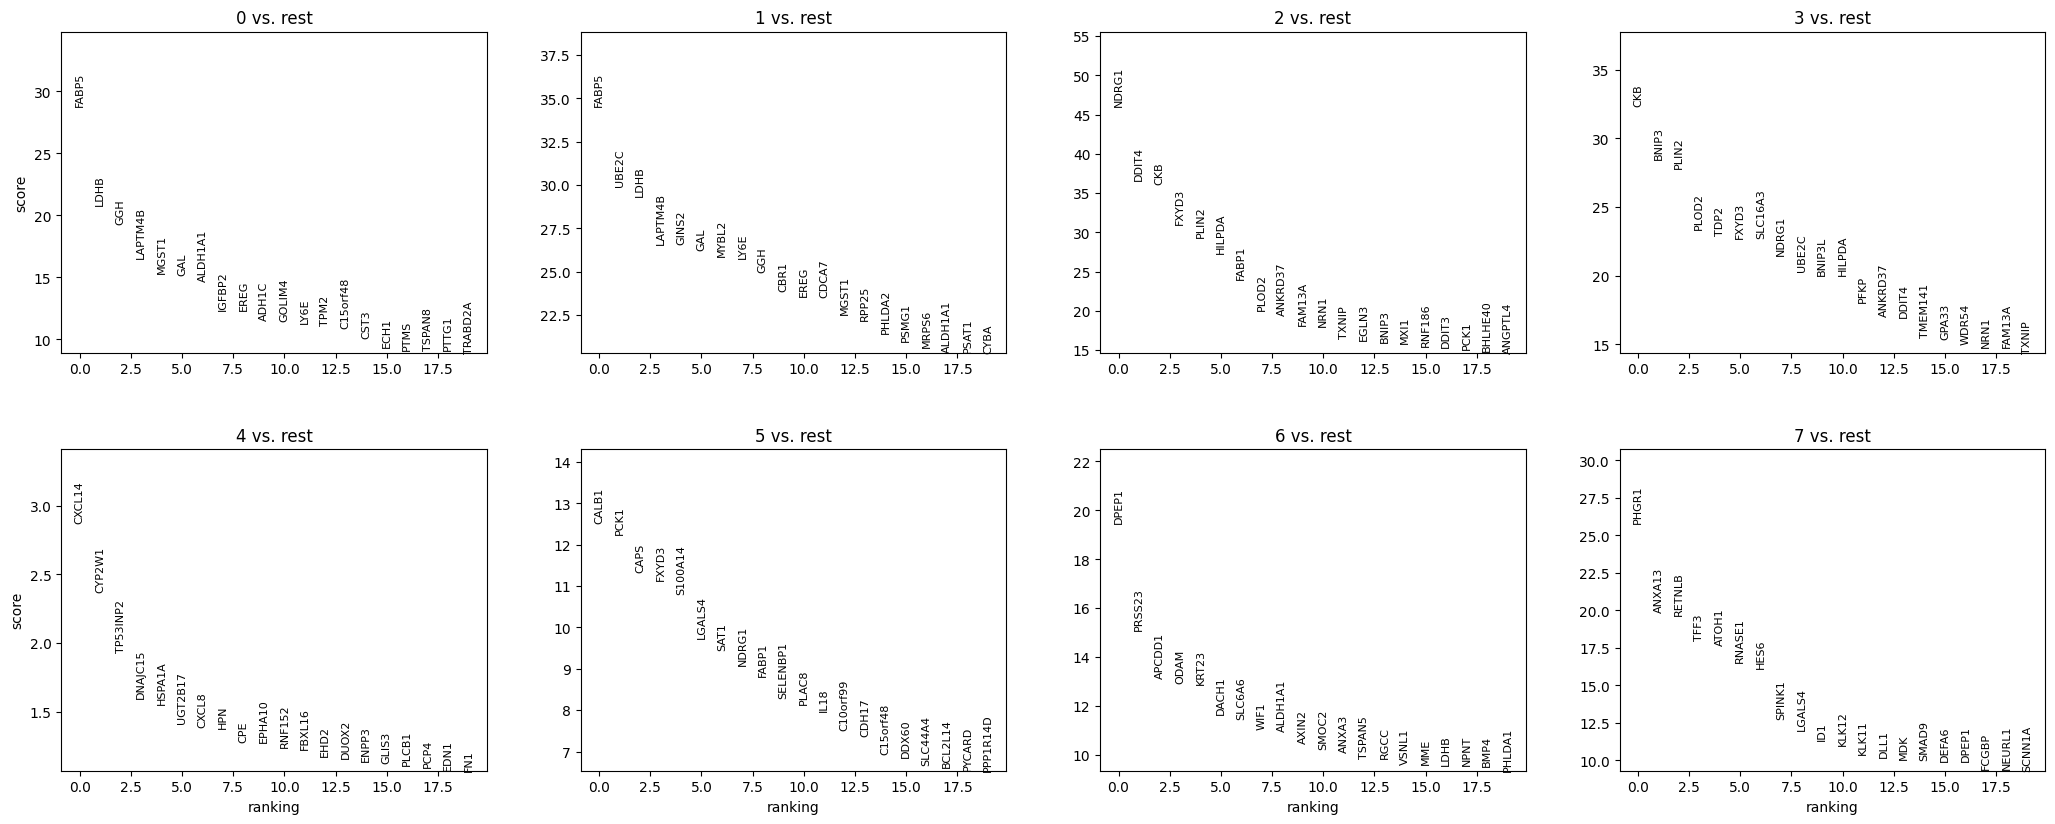

In [25]:
sc.tl.rank_genes_groups(adata_selected, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(adata_selected, n_genes=20, sharey=False)


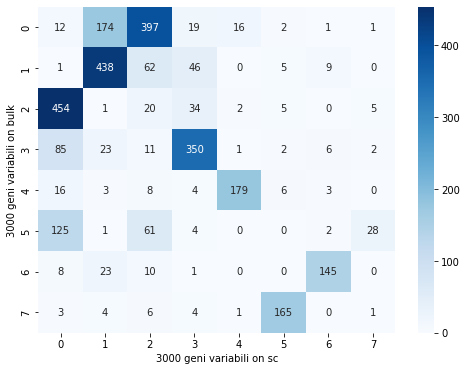

In [106]:
#CONFRONTO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
common_cells = list(set(adata_selected.obs_names) & set(adata_nosel.obs_names))
adata_selected = adata_selected[common_cells]
adata_nosel = adata_nosel[common_cells]
clusters = adata_selected.obs["leiden"].astype(str)  
clusters_nosel= adata_nosel.obs["leiden"].astype(str) 
conf_mat = confusion_matrix(clusters, clusters_nosel)

conf_df = pd.DataFrame(conf_mat)

plt.figure(figsize=(8,6))
sns.heatmap(conf_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("3000 geni variabili on sc")
plt.ylabel("3000 geni variabili on bulk")

plt.show()
